In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score


In [2]:
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split
from utils.check_multicollinearity import check_multicollinearity 
from utils.calculate_regression_metrics import calculate_regression_metrics

In [3]:
MACRO_COLS = ['CPI_Change', 'Rate_Change', 'GDP_Growth', 'Unemp_Change', 'USD_Change', 'VIX_Change', 'Credit_Spread']
LAGGED_COLS =[
    'CPI_Change_lag1',
    'GDP_Growth_lag2',
    'Unemp_Change_lag1',
    'Credit_Spread_lag2'
    ]
# remove some features cols and run several times to see how it affects the performance

In [4]:
df = pd.read_csv('../data/processed/processed_data.csv',parse_dates=['Date'])

# df.info()

# Prepare Data without Lags
splits_data = data_split(df,MACRO_COLS)

X_train = splits_data['X_train']
y_train = splits_data['y_train']

X_test  = splits_data['X_test']
y_test  = splits_data['y_test']


print(X_train)


  Train       n= 334  1991-03-01 to 2018-12-01  μ=0.58%  σ=4.09%

  Test        n=  81  2019-01-01 to 2025-09-01  μ=1.21%  σ=4.85%

  Features (7): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread
[[ 0.         -0.13        2.75236735 ...  6.03342959 -3.85421053
   1.16      ]
 [ 0.3        -0.21        2.79921504 ...  3.20493409 -0.37148325
   1.08      ]
 [ 0.5        -0.13        2.86300483 ...  0.84233277 -0.44045455
   1.        ]
 ...
 [ 0.59        0.24        4.39574353 ...  1.11313474  6.4416476
   0.93      ]
 [-0.178       0.01        4.11004869 ...  0.90881945  0.03687371
   1.        ]
 [ 0.173       0.07        3.93763194 ...  0.11436101  5.56411028
   1.11      ]]


In [5]:

# MODEL 1: Linear Regression (7 variables, NO lags)

print("\n" + "="*50)
print("MODEL 1: Linear Regression (7 Variables - Baseline)")
print("="*50)


scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_scaled  = scaler.transform(X_test)


# Train model
model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)

# Predict
y_train_pred_1 = model_1.predict(X_train_scaled)
y_test_pred_1 = model_1.predict(X_test_scaled)



# Evaluate
# print("\nTRAINING SET:")
metrics_train_1 = calculate_regression_metrics(y_train, y_train_pred_1, "Model 1 - Train")

# print("\nTEST SET:")
metrics_test_1 = calculate_regression_metrics(y_test, y_test_pred_1, "Model 1 - Test")

# Print coefficients
coef_df_1 = pd.DataFrame({
    'Feature': MACRO_COLS,
    'Coefficient': model_1.coef_,
    'Abs_Coef': np.abs(model_1.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS:")
print(coef_df_1.to_string(index=False))


MODEL 1: Linear Regression (7 Variables - Baseline)

Model 1 - Train Performance:
  R²:                  0.3724
  RMSE:                3.239%
  MAE:                 2.448%
  Directional Accuracy: 74.85%

Model 1 - Test Performance:
  R²:                  0.0834
  RMSE:                4.639%
  MAE:                 3.364%
  Directional Accuracy: 76.54%

COEFFICIENTS:
      Feature  Coefficient  Abs_Coef
   VIX_Change    -2.362182  2.362182
Credit_Spread    -0.815101  0.815101
   USD_Change    -0.536430  0.536430
 Unemp_Change    -0.309586  0.309586
   CPI_Change    -0.227893  0.227893
  Rate_Change    -0.212436  0.212436
   GDP_Growth    -0.089410  0.089410


In [6]:
splits_data = data_split(df,MACRO_COLS + LAGGED_COLS)

X_train_lagged = splits_data['X_train']
y_train_lagged = splits_data['y_train']

X_test_lagged  = splits_data['X_test']
y_test_lagged  = splits_data['y_test']


  Train       n= 334  1991-03-01 to 2018-12-01  μ=0.58%  σ=4.09%

  Test        n=  81  2019-01-01 to 2025-09-01  μ=1.21%  σ=4.85%

  Features (11): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread, CPI_Change_lag1, GDP_Growth_lag2, Unemp_Change_lag1, Credit_Spread_lag2


In [7]:

# MODEL 2: Linear Regression With lags


print("\n" + "="*50)
print("MODEL 2: Linear Regression with lags")
print("="*50)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lagged)   # fit + transform on TRAIN only
X_test_scaled  = scaler.transform(X_test_lagged)

# Train model
model_2 = LinearRegression()
model_2.fit(X_train_lagged, y_train_lagged)

# Predict
y_train_pred_2 = model_2.predict(X_train_lagged)
y_test_pred_2 = model_2.predict(X_test_lagged)

# Evaluate
print("\nTRAINING SET:")
metrics_train_2 = calculate_regression_metrics(y_train_lagged, y_train_pred_2, "Model 2 - Train")

print("\nTEST SET:")
metrics_test_2 = calculate_regression_metrics(y_test_lagged, y_test_pred_2, "Model 2 - Test")

# Print coefficients
coef_df_2 = pd.DataFrame({
    'Feature': MACRO_COLS + LAGGED_COLS,
    'Coefficient': model_2.coef_,
    'Abs_Coef': np.abs(model_2.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS:")





MODEL 2: Linear Regression with lags

TRAINING SET:

Model 2 - Train Performance:
  R²:                  0.3869
  RMSE:                3.201%
  MAE:                 2.421%
  Directional Accuracy: 74.55%

TEST SET:

Model 2 - Test Performance:
  R²:                  -0.3923
  RMSE:                5.717%
  MAE:                 4.007%
  Directional Accuracy: 69.14%

COEFFICIENTS:


In [8]:
print(coef_df_2.to_string(index=False))

           Feature  Coefficient  Abs_Coef
 Unemp_Change_lag1    -2.171723  2.171723
      Unemp_Change    -2.014194  2.014194
       Rate_Change    -1.864368  1.864368
     Credit_Spread    -1.743076  1.743076
        VIX_Change    -0.662085  0.662085
        CPI_Change    -0.592687  0.592687
   GDP_Growth_lag2    -0.589845  0.589845
        GDP_Growth     0.558756  0.558756
   CPI_Change_lag1     0.474222  0.474222
Credit_Spread_lag2     0.353070  0.353070
        USD_Change    -0.295390  0.295390


In [9]:
# Check for multicollinearity

X_train_lagged_df = pd.DataFrame(X_train_lagged, columns=MACRO_COLS + LAGGED_COLS)
print("\nMULTICOLLINEARITY CHECK (VIF):")
vif_results = check_multicollinearity(X_train_lagged_df, threshold=5.0)


MULTICOLLINEARITY CHECK (VIF):

Variance Inflation Factor (VIF):
           Feature       VIF Concern
   GDP_Growth_lag2 88.050444    High
        GDP_Growth 87.643290    High
     Credit_Spread 51.575189    High
Credit_Spread_lag2 49.513094    High
        CPI_Change  2.219338      OK
   CPI_Change_lag1  1.951917      OK
 Unemp_Change_lag1  1.302293      OK
      Unemp_Change  1.267530      OK
       Rate_Change  1.254042      OK
        VIX_Change  1.105708      OK
        USD_Change  1.093013      OK

Note: VIF > 5.0 indicates multicollinearity concern


In [10]:
# MODEL 3: Ridge Regression

print("\n" + "="*50)
print("MODEL 3: Ridge Regression")
print("="*50)


alphas = np.logspace(-3, 5, 100)

# Manually compute CV score for each alpha
cv_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(
        ridge, 
        X_train_lagged, 
        y_train_lagged, 
        cv=5, 
        scoring='r2'
    )
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)

# Find best alpha manually
best_alpha = alphas[np.argmax(cv_scores)]
print(f"Best alpha: {best_alpha:.4f}")


MODEL 3: Ridge Regression
Best alpha: 40.3702


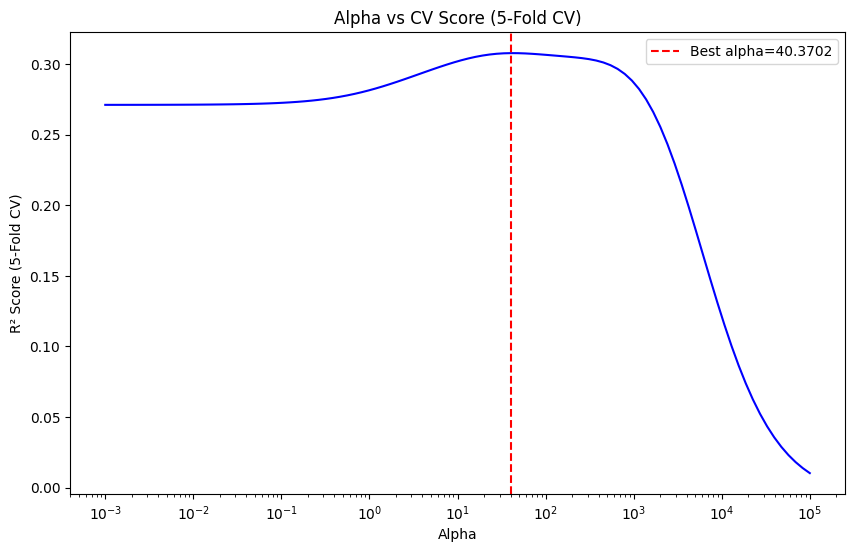

In [11]:
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, cv_scores, color='blue')
plt.axvline(best_alpha, color='red', linestyle='--',
            label=f'Best alpha={best_alpha:.4f}')
plt.xlabel('Alpha')
plt.ylabel('R² Score (5-Fold CV)')
plt.title('Alpha vs CV Score (5-Fold CV)')
plt.legend()
plt.show()

In [12]:

# Train final Ridge model with best alpha

model_3_ridge = Ridge(alpha=best_alpha)
model_3_ridge.fit(X_train_lagged, y_train_lagged)

# Predict
y_train_pred_3 = model_3_ridge.predict(X_train_lagged)
y_test_pred_3 = model_3_ridge.predict(X_test_lagged)

# Evaluate
print("\nTRAINING SET:")
metrics_train_3 = calculate_regression_metrics(y_train_lagged, y_train_pred_3, "Model 3 - Train")

print("\nTEST SET:")
metrics_test_3 = calculate_regression_metrics(y_test_lagged, y_test_pred_3, "Model 3 - Test")

# Print coefficients (on scaled features)
coef_df_3 = pd.DataFrame({
    'Feature': MACRO_COLS + LAGGED_COLS,
    'Coefficient': model_3_ridge.coef_,
    'Abs_Coef': np.abs(model_3_ridge.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS (on standardized scale):")
print(coef_df_3.to_string(index=False))


TRAINING SET:

Model 3 - Train Performance:
  R²:                  0.3723
  RMSE:                3.239%
  MAE:                 2.459%
  Directional Accuracy: 74.25%

TEST SET:

Model 3 - Test Performance:
  R²:                  0.2728
  RMSE:                4.132%
  MAE:                 3.136%
  Directional Accuracy: 74.07%

COEFFICIENTS (on standardized scale):
           Feature  Coefficient  Abs_Coef
        VIX_Change    -0.644009  0.644009
     Credit_Spread    -0.605778  0.605778
        GDP_Growth     0.455828  0.455828
Credit_Spread_lag2    -0.423852  0.423852
   GDP_Growth_lag2    -0.387956  0.387956
   CPI_Change_lag1     0.348050  0.348050
      Unemp_Change    -0.300813  0.300813
 Unemp_Change_lag1    -0.297817  0.297817
        CPI_Change    -0.285525  0.285525
        USD_Change    -0.272062  0.272062
       Rate_Change    -0.186388  0.186388


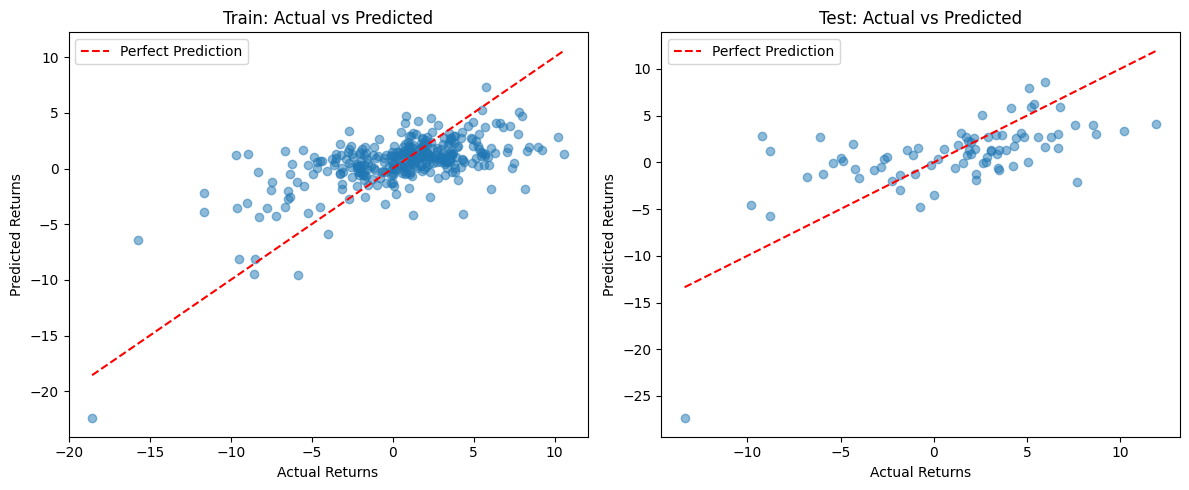

In [13]:
plt.figure(figsize=(12, 5))

# Train
plt.subplot(1, 2, 1)
plt.scatter(y_train_lagged, y_train_pred_3, alpha=0.5)
plt.plot([y_train_lagged.min(), y_train_lagged.max()],
         [y_train_lagged.min(), y_train_lagged.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title(f'Train: Actual vs Predicted')
plt.legend()

# Test
plt.subplot(1, 2, 2)
plt.scatter(y_test_lagged, y_test_pred_3, alpha=0.5)
plt.plot([y_test_lagged.min(), y_test_lagged.max()],
         [y_test_lagged.min(), y_test_lagged.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title(f'Test: Actual vs Predicted')
plt.legend()

plt.tight_layout()
plt.show()

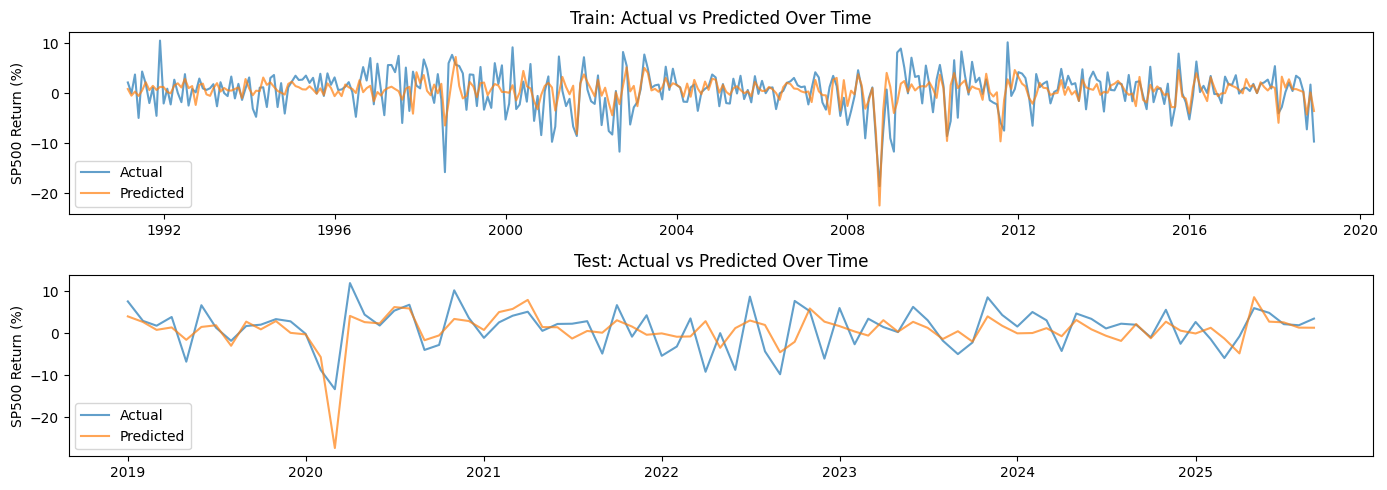

In [14]:
plt.figure(figsize=(14, 5))

dates_train,dates_test = splits_data['dates_train'], splits_data['dates_test']  
# Train
plt.subplot(2, 1, 1)
plt.plot(dates_train, y_train_lagged, label='Actual', alpha=0.7)
plt.plot(dates_train, y_train_pred_3,  label='Predicted', alpha=0.7)
plt.title('Train: Actual vs Predicted Over Time')
plt.ylabel('SP500 Return (%)')
plt.legend()

# Test
plt.subplot(2, 1, 2)
plt.plot(dates_test, y_test_lagged, label='Actual', alpha=0.7)
plt.plot(dates_test, y_test_pred_3,  label='Predicted', alpha=0.7)
plt.title('Test: Actual vs Predicted Over Time')
plt.ylabel('SP500 Return (%)')
plt.legend()

plt.tight_layout()
plt.show()

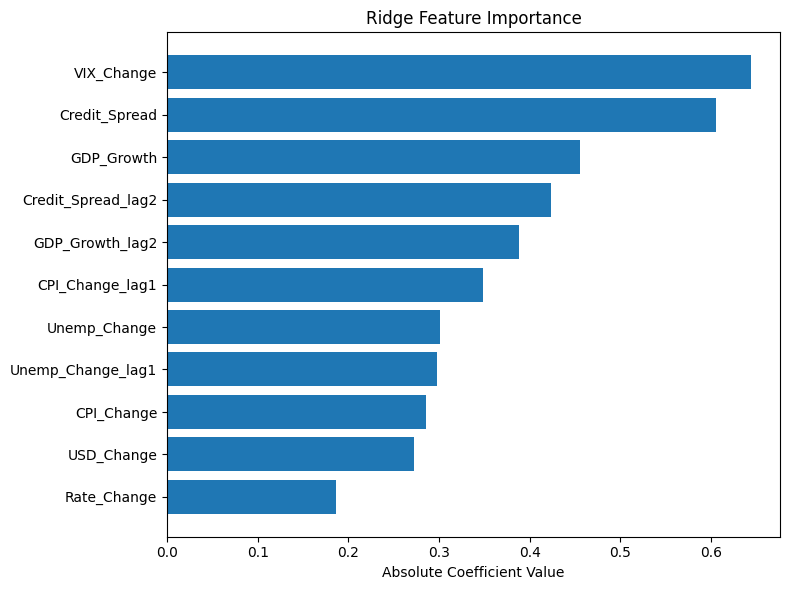

In [15]:
coef_df = pd.DataFrame({
    'Feature'    : MACRO_COLS + LAGGED_COLS,
    'Coefficient': np.abs(model_3_ridge.coef_)
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Ridge Feature Importance')
plt.tight_layout()
plt.show()